# Lattice-encrypted OFDM Simulation using Modular Library
This notebook imports the modular functions from `simulation_library` and executes the full simulation pipeline in a single cell, outputting all requested visualizations and metrics.

In [1]:
%load_ext autoreload
%autoreload 2

# 1. Import libraries
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import sionna.phy

# IPython magic function for inline plots
%matplotlib inline

# Import from our modular library
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from metrics import hadamard_ratio, hadamard_quality, matrix_condition_number, random_unimodular_matrix, generate_lattice_bases
from ber import bit_error_rate, nearest_neighbor_qam_demapper, db_to_linear_amplitude, receiver_amplifier
from plots import plot_constellation, plot_rx_only, plot_signal_snapshot, plot_zoomed_signal, plot_noisy_time_domain

## End-to-End Simulation & Visualizations
Run the cell below to execute the full chain (Data generation -> Mapping -> Encryption -> OFDM modulation -> Attenuating AWGN Channel -> Receiver Amplifier -> Equalized Demodulation -> Linear/Babai decryption -> Hard Demapping) and plot the results.


--- FIG 8(a): TRANSMITTED QAM CONSTELLATION ---


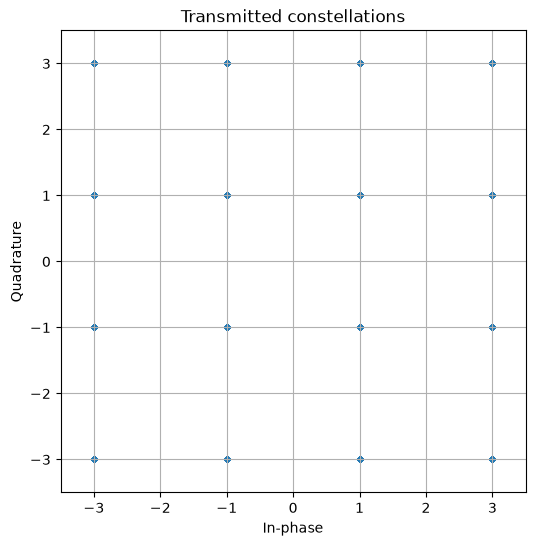

R quality: good  HR(R)=8.3192e-01  rho_R=0.4381
B quality: NOT below badTh  HR(B)=7.6560e-01  rho_B=1.9048
Usable error scale: 2.6250e-01 < sigma < 1.1412e+00
Private basis R shape: (512, 512) | Public basis B shape: (512, 512)
sigma = 1.0271e+00  (window 2.625e-01 .. 1.141e+00)

--- ENCRYPTED SIGNAL CONSTELLATION ---


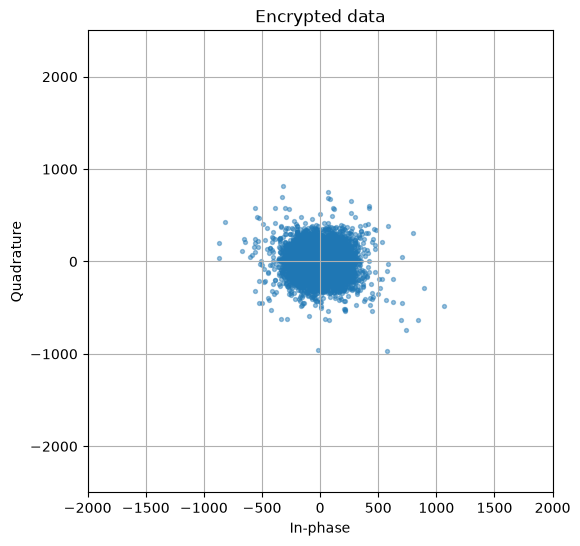


--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---


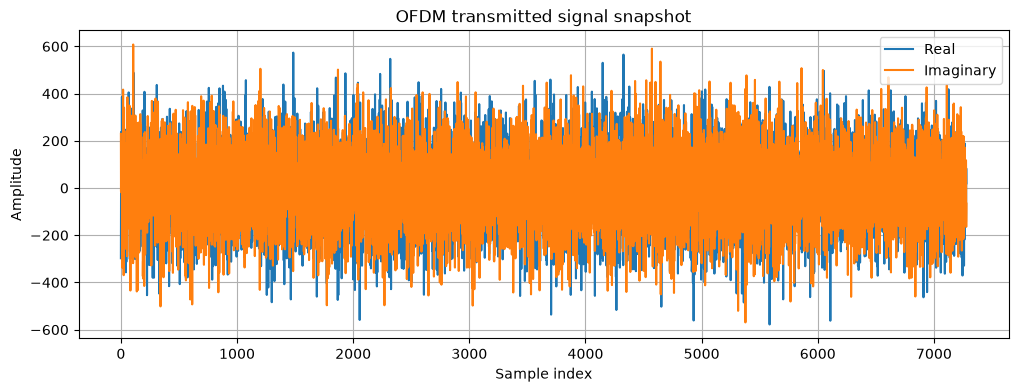

t0: symbol = -297.4904+229.5085j, I = -297.4904, Q = 229.5085
t1: symbol = 0.8998-14.6648j, I = 0.8998, Q = -14.6648
t2: symbol = 115.2267+104.4472j, I = 115.2267, Q = 104.4472
t3: symbol = 209.6252+25.5027j, I = 209.6252, Q = 25.5027


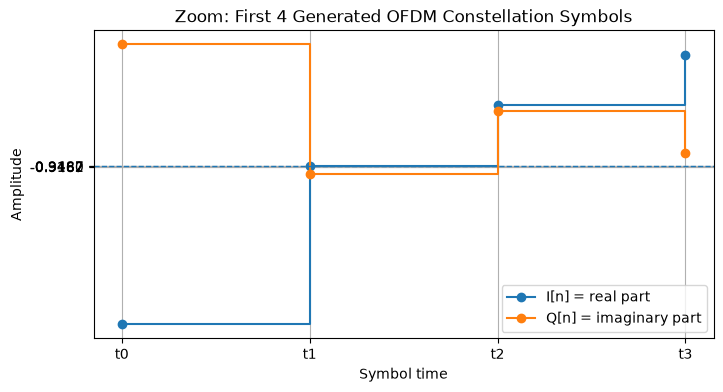

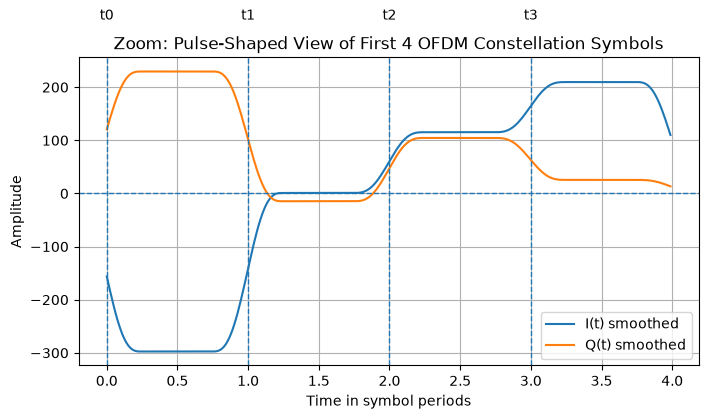


--- NOISY TIME DOMAIN ---


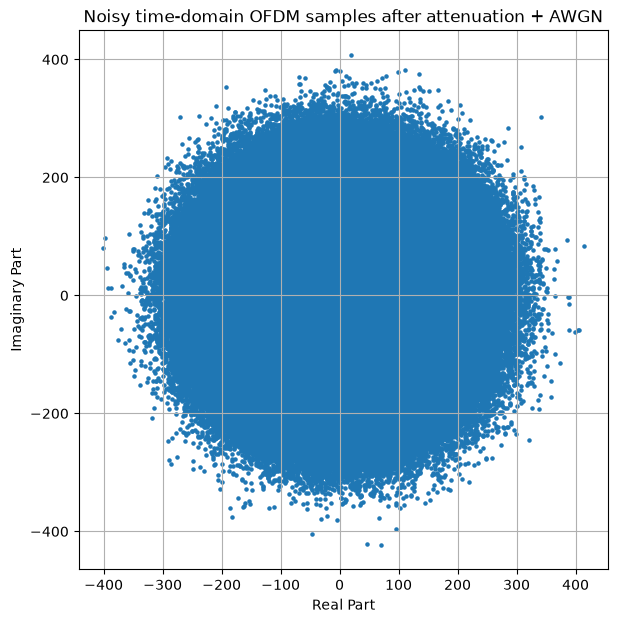


 RECEIVED CONSTELLATION (linear decrypt, before hard slicer) 


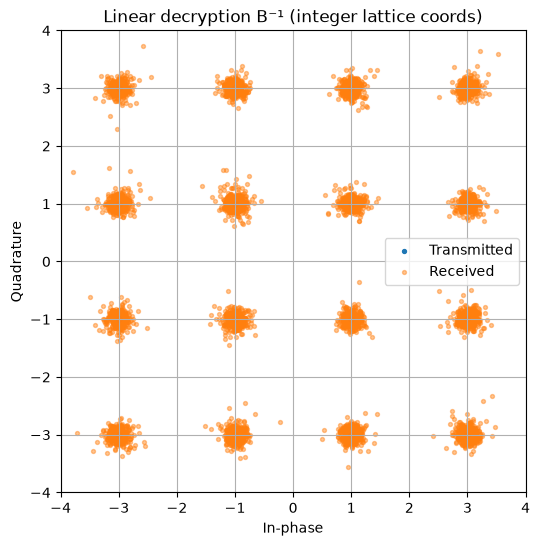


--- RESULTS ---
BER (Babai + hard slicer) at 28 dB:  0.000000e+00


In [2]:
import contextlib
# --- PARAMETERS (Abdallah 2024) ---
batch_size = 1000
num_bits_per_symbol = 4          # 16-QAM -> 4 bits/symbol
fft_size = 512                   # lattice dim = sub-carriers; must be > 350 (Sec. 4.3)
num_ofdm_symbols = 14
cyclic_prefix_length = 8
ebno_db_plot = 28                # Eb/N0 for constellation plot — linear decrypt gives clouds at 28dB
ebno_db      = 28                # Eb/N0 for BER measurement
channel_attenuation = 0.5
receiver_gain_db = 7.0

# ── 1. Generate bits ──────────────────────────────────────────────────────────
binary_source = sionna.phy.mapping.BinarySource()
bits = binary_source([batch_size, num_ofdm_symbols, fft_size, num_bits_per_symbol])

# ── 2. QAM mapping (Sionna normalised symbols) ────────────────────────────────
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
symbols = mapper(bits)           # unit-power, shape [batch, ofdm_syms, fft_size, 1]

# ── 3. Scale to integer lattice coordinates {±1, ±3}  (Fig. 8a) ──────────────
qam_lattice_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float32))
symbols_lattice = symbols.squeeze(-1) * qam_lattice_scale.to(symbols.device)

# Fig 8(a): clean transmitted constellation
print("\n--- FIG 8(a): TRANSMITTED QAM CONSTELLATION ---")
plot_rx_only(symbols_lattice[0], "Transmitted constellations", limit=3.5)

# ── 4. Lattice encryption  C = B·S + E  (Algorithm 2) ────────────────────────
encryptor = LatticeBasedEncryptor(
    n=fft_size,
    sigma=None,   # auto-selected in window  1/(2*rho_B) < sigma < 1/(2*rho_R)
)
encrypted_symbols = encryptor.encrypt(symbols_lattice)   # complex64

# Fig 8(b): encrypted constellation — noise cloud
print("\n--- ENCRYPTED SIGNAL CONSTELLATION ---")
plot_rx_only(encrypted_symbols[0], "Encrypted data", xlim=2000, ylim=2500)

# ── 5. OFDM modulation: IFFT + cyclic prefix (Eq. 7) ─────────────────────────
ofdm_modulator = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length)
tx_signal = ofdm_modulator(encrypted_symbols.to(torch.complex64))

print("\n--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---")
plot_signal_snapshot(tx_signal)
plot_zoomed_signal(tx_signal, n_symbols=4, samples_per_symbol=80)

# ── 6. AWGN channel ───────────────────────────────────────────────────────────
# N0 must be computed relative to the ACTUAL transmitted signal power (after
# IFFT and attenuation), not the QAM symbol power. The OFDMModulator does not
# normalise away the basis-projection gain, so tx_att is ~39 dB stronger than
# the original QAM symbols. Using QAM power as the reference would make N0
# tiny and noise invisible after decryption.-
#
# Eb/N0 = tx_power / (bits_per_symbol * N0)  =>  N0 = tx_power / (bps * Eb/N0)
# This is exactly what Sionna's ebnodb2no does, but anchored to the real tx power.

tx_signal_attenuated = channel_attenuation * tx_signal
tx_power = (tx_signal_attenuated.abs() ** 2).mean().item()

def noise_var_from_ebno(ebno_db):
    return tx_power / (num_bits_per_symbol * 10 ** (ebno_db / 10))

awgn = sionna.phy.channel.AWGN()
rx_signal_plot = awgn(tx_signal_attenuated,
                      torch.tensor(noise_var_from_ebno(ebno_db_plot)))

print("\n--- NOISY TIME DOMAIN ---")
plot_noisy_time_domain(rx_signal_plot)

# ── 7. Receiver: amplify → FFT → equalise ────────────────────────────────────
rx_signal_amp = receiver_amplifier(rx_signal_plot, gain_db=receiver_gain_db)
ofdm_demodulator = sionna.phy.ofdm.OFDMDemodulator(
    fft_size=fft_size,
    cyclic_prefix_length=cyclic_prefix_length,
    l_min=0
)
rx_symbols = ofdm_demodulator(rx_signal_amp)
effective_gain = channel_attenuation * db_to_linear_amplitude(receiver_gain_db)
rx_symbols_equalized = rx_symbols / effective_gain

# ── 8. Linear decryption for Fig 8(c) constellation plot ─────────────────────
#
#   received OFDM → FFT → B⁻¹ (linear) → [Fig 8c here] → Babai → hard slicer
#
# Abdallah's Fig 8(c) shows 16 Gaussian clouds — continuous float spread around
# each constellation point. This can only come from LINEAR decryption (multiply
# by B⁻¹, no rounding). Babai round-off snaps everything to exact integers,
# which produces a discrete grid of wrong/right integers rather than clouds.
# The linear path lets the residual AWGN show as visible scatter, exactly
# matching the paper's figure. Babai is still used for BER (step 9 below).
decrypted_linear = encryptor.decrypt_linear(rx_symbols_equalized).to(torch.complex64)

print("\n RECEIVED CONSTELLATION (linear decrypt, before hard slicer) ")
plot_constellation(
    symbols_lattice[0],
    decrypted_linear[0],
    "Linear decryption B⁻¹ (integer lattice coords)",
    limit=4
)

# ── 9. BER at ebno_db (separate channel pass) ─────────────────────────────────
rx_signal_ber = awgn(tx_signal_attenuated,
                     torch.tensor(noise_var_from_ebno(ebno_db)))
rx_amp_ber    = receiver_amplifier(rx_signal_ber, gain_db=receiver_gain_db)
rx_sym_ber    = ofdm_demodulator(rx_amp_ber) / effective_gain

decrypted_ber         = encryptor.decrypt_w_babai(rx_sym_ber, use_round=True)
decrypted_sliced      = qam16_slicer_lattice(decrypted_ber)
decrypted_symbols_ber = qam16_lattice_to_normalized(decrypted_sliced)
recovered_bits_babai  = nearest_neighbor_qam_demapper(
    decrypted_symbols_ber, mapper, num_bits_per_symbol
)
ber_babai = bit_error_rate(bits, recovered_bits_babai)

print("\n--- RESULTS ---")
print(f"BER (Babai + hard slicer) at {ebno_db} dB:  {ber_babai:.6e}")


## Monte Carlo: BER vs SNR for different lattice dimensions
Each SNR point is repeated until a 98% confidence interval is reached for dimensions N ∈ {256, 350, 400, 512}.


=== N = 256 ===
R quality: good  HR(R)=9.0517e-01  rho_R=0.1936
B quality: NOT below badTh  HR(B)=1.8899e-02  rho_B=937.9976
Usable error scale: 5.3305e-04 < sigma < 2.5826e+00
Private basis R shape: (256, 256) | Public basis B shape: (256, 256)
sigma = 1.0000e+00  (window 5.331e-04 .. 2.583e+00)
NOTE: lattice dimension n=256 < 350. Abdallah Sec. 4.3 requires n > 350 (>=400 to resist GGH/NTRU cryptanalysis) for security; smaller n is for performance study only.
SNR=  0.0 dB  BER=4.999e-01  +/-7.93e-04 (98% CI, n=5)
SNR=  5.0 dB  BER=4.999e-01  +/-5.42e-04 (98% CI, n=5)
SNR= 10.0 dB  BER=4.999e-01  +/-2.40e-04 (98% CI, n=5)
SNR= 15.0 dB  BER=4.997e-01  +/-9.40e-04 (98% CI, n=5)
SNR= 20.0 dB  BER=4.996e-01  +/-7.22e-04 (98% CI, n=5)
SNR= 25.0 dB  BER=4.989e-01  +/-4.80e-04 (98% CI, n=5)
SNR= 30.0 dB  BER=4.982e-01  +/-7.81e-04 (98% CI, n=5)
SNR= 35.0 dB  BER=4.970e-01  +/-5.48e-04 (98% CI, n=5)
SNR= 40.0 dB  BER=4.951e-01  +/-8.41e-04 (98% CI, n=5)
SNR= 45.0 dB  BER=4.912e-01  +/-8.74e-

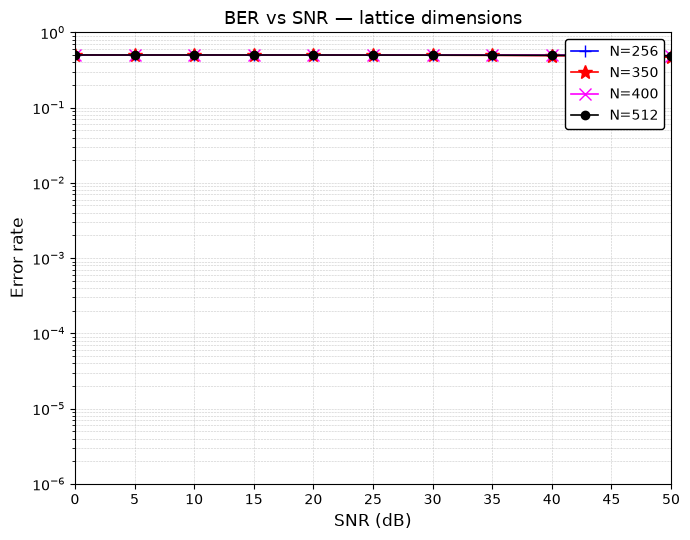

In [3]:
from ber import snr_sweep_ber, plot_ber_vs_snr

# SNR range matching Abdallah Fig. 5 (0-50 dB)
snr_list = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# ---- Abdallah Fig. 5 methodology ----
# k=48: rho_R grows with N, sigma=1 margin tightens from 0.31 (N=256) to 0.07 (N=512).
# k=64 was too well-conditioned (margin 0.29-0.39), bunching all curves together.
# num_ops scales with N so the public basis B is properly degraded,
# giving larger tx power for larger N (pushes waterfall further right).
FIXED_SIGMA = 1
FIXED_K     = 48

dimensions = [256, 350, 400, 512]
results_by_label = {}

for n_dim in dimensions:
    print(f"\n=== N = {n_dim} ===")

    enc_mc = LatticeBasedEncryptor(
        n=n_dim,
        sigma=FIXED_SIGMA,
        k=FIXED_K,
        num_ops=max(150, 3 * n_dim),  # scale with N for proper B degradation
        max_coeff=3,                    # stronger unimodular mixing
        verbose=True,
    )

    mod_mc   = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length)
    demod_mc = sionna.phy.ofdm.OFDMDemodulator(
        fft_size=n_dim,
        cyclic_prefix_length=cyclic_prefix_length,
        l_min=0
    )

    def run_once(snr_db, seed, _enc=enc_mc, _mod=mod_mc, _demod=demod_mc, _n=n_dim):
        torch.manual_seed(seed)

        bits_mc   = binary_source([100, num_ofdm_symbols, _n, num_bits_per_symbol])
        syms_mc   = mapper(bits_mc)
        lat_mc    = syms_mc.squeeze(-1) * qam_lattice_scale.to(syms_mc.device)

        enc_sym   = _enc.encrypt(lat_mc)
        tx_mc     = _mod(enc_sym.to(torch.complex64))
        tx_att_mc = channel_attenuation * tx_mc

        tx_pow_mc = (tx_att_mc.abs() ** 2).mean().item()
        N0_mc     = tx_pow_mc / (num_bits_per_symbol * 10 ** (snr_db / 10))

        rx_mc     = awgn(tx_att_mc, torch.tensor(N0_mc))
        rx_amp_mc = receiver_amplifier(rx_mc, gain_db=receiver_gain_db)
        rx_eq_mc  = _demod(rx_amp_mc) / effective_gain

        dec_mc    = _enc.decrypt_w_babai(rx_eq_mc, use_round=True)
        sl_mc     = qam16_slicer_lattice(dec_mc)
        sym_mc    = qam16_lattice_to_normalized(sl_mc)
        rb_mc     = nearest_neighbor_qam_demapper(sym_mc, mapper, num_bits_per_symbol)
        return float(bit_error_rate(bits_mc, rb_mc))

    results_by_label[f"N={n_dim}"] = snr_sweep_ber(
        run_once, snr_list, min_reps=5, max_reps=30
    )

plot_ber_vs_snr(results_by_label, title="BER vs SNR — lattice dimensions")


## Point 4 — Lattice dimension > 350
The lattice dimension equals `fft_size` (number of OFDM sub-carriers). Abdallah Sec. 4.3 requires it to exceed 350 (≥400 to resist GGH/NTRU cryptanalysis). `fft_size=512` above satisfies this. Fig. 5 of the paper sweeps N ∈ {32, 64, 128, 256, 512}; only N ≥ 400 is security-relevant.